### Imports et configuration

In [25]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
import itertools

%matplotlib inline

### Chargement des données

In [2]:
def load_metadata_and_counts(dataset_dir: str) -> pd.DataFrame:
    """Lit les fichiers labels YOLO pour compter les insectes par image."""
    base_path = Path(dataset_dir)
    images_dir = base_path / "images"
    labels_dir = base_path / "labels"
    
    data = []
    
    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
            
        jour = img_path.name[:8]
        label_path = labels_dir / img_path.with_suffix(".txt").name
        
        insect_count = 0
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                insect_count = len(lines)
                
        data.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "jour": jour,
            "insect_count": insect_count
        })
        
    return pd.DataFrame(data)

# Chargement depuis le sous-dossier de 'data' (ajuste le ../ si ton notebook est à la racine)
DATASET_DIR = "../data/merged_filtered_dataset" 

print("Analyse des fichiers et comptage des insectes en cours...")
df = load_metadata_and_counts(DATASET_DIR)

# Afficher les 5 premières lignes pour vérifier interactivement
df.head()

Analyse des fichiers et comptage des insectes en cours...


,image_name,image_path,jour,insect_count
0,20221006_09-03-49-024129_raw_jpg.rf.4df65bba71...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
1,20221006_09-11-26-908410_raw_jpg.rf.d17c0ef063...,..\data\merged_filtered_dataset\images\2022100...,20221006,0
2,20221006_09-14-31-840309_raw_jpg.rf.28d2caeab7...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
3,20221006_09-14-34-972005_raw_jpg.rf.5a5d09316b...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
4,20221006_09-14-44-434197_raw_jpg.rf.b0129cf391...,..\data\merged_filtered_dataset\images\2022100...,20221006,1


### Séparation des données (ajustement / test)

In [3]:
# Définition stricte des ensembles d'ajustement et de test
jours_ajustement = ['20221006', '20221007', '20221012', '20221017']
jours_test = ['20221018', '20221019', '20221020']

# Séparation du DataFrame
df_ajustement = df[df['jour'].isin(jours_ajustement)].copy()
df_test = df[df['jour'].isin(jours_test)].copy()

print(f"Images pour l'ajustement (développement) : {len(df_ajustement)}")
print(f"Images pour le test (évaluation finale)  : {len(df_test)}")

Images pour l'ajustement (développement) : 702
Images pour le test (évaluation finale)  : 399


### Implémentation d'un Background Subtractor (MOG2)

In [18]:
def apply_mog2_chronological_tuned(df: pd.DataFrame, day: str, 
                                   history: int = 15, 
                                   var_threshold: float = 30, 
                                   learning_rate: float = 0.01):
    """
    Applique MOG2 de manière strictement chronologique.
    - var_threshold : Baisse ce chiffre si l'algo rate des insectes (augmente la sensibilité).
                      Monte-le s'il détecte trop de bruit/ombres.
    - learning_rate : Vitesse d'adaptation au soleil (0 = figé, 1 = oublie tout à chaque image).
    """
    df_day = df[df['jour'] == day].sort_values("image_name")
    
    # Initialisation avec les paramètres ajustables
    backSub = cv2.createBackgroundSubtractorMOG2(history=history, 
                                                 varThreshold=var_threshold, 
                                                 detectShadows=True)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    
    results = []
    
    # Passage unique et chronologique
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: 
            continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Le learning_rate est constant ici, permettant une adaptation fluide
        fg_mask_raw = backSub.apply(img_blur, learningRate=learning_rate)
        
        # Suppression des ombres
        _, fg_mask_no_shadows = cv2.threshold(fg_mask_raw, 200, 255, cv2.THRESH_BINARY)
        
        # Nettoyage
        fg_mask_clean = cv2.morphologyEx(fg_mask_no_shadows, cv2.MORPH_OPEN, kernel)
        
        results.append({
            'image_name': row['image_name'],
            'original': img,
            'mask_raw': fg_mask_raw,
            'mask_clean': fg_mask_clean
        })
        
    return results

### Visualisation des masques créés par le MOG2 sur des images des jours d'ajustement


TRAITEMENT DE LA JOURNÉE : 20221006


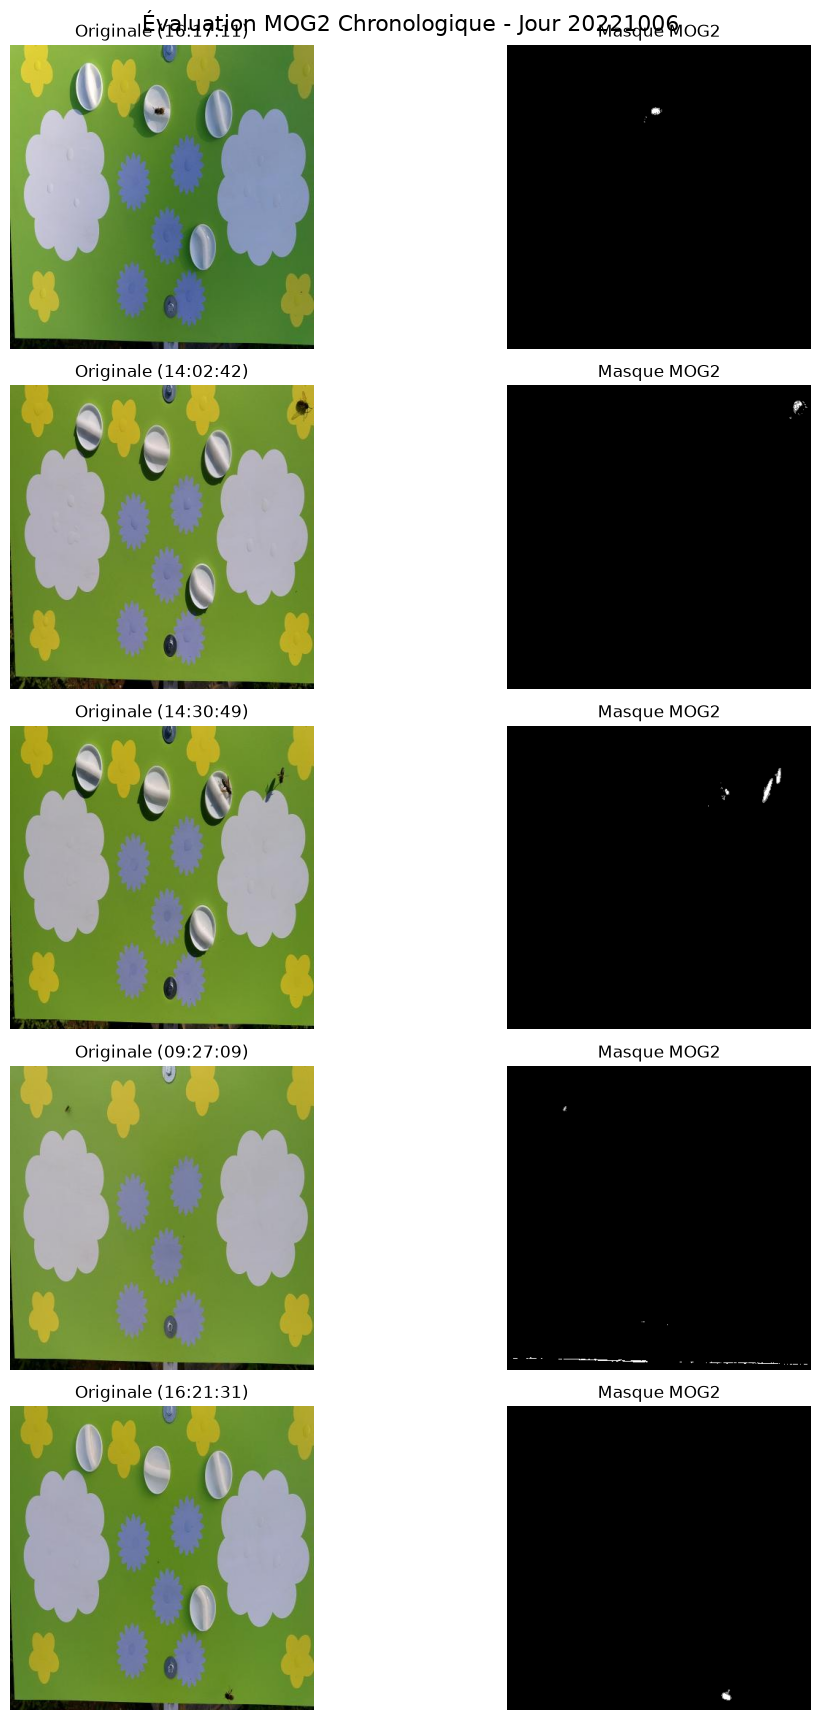


TRAITEMENT DE LA JOURNÉE : 20221007


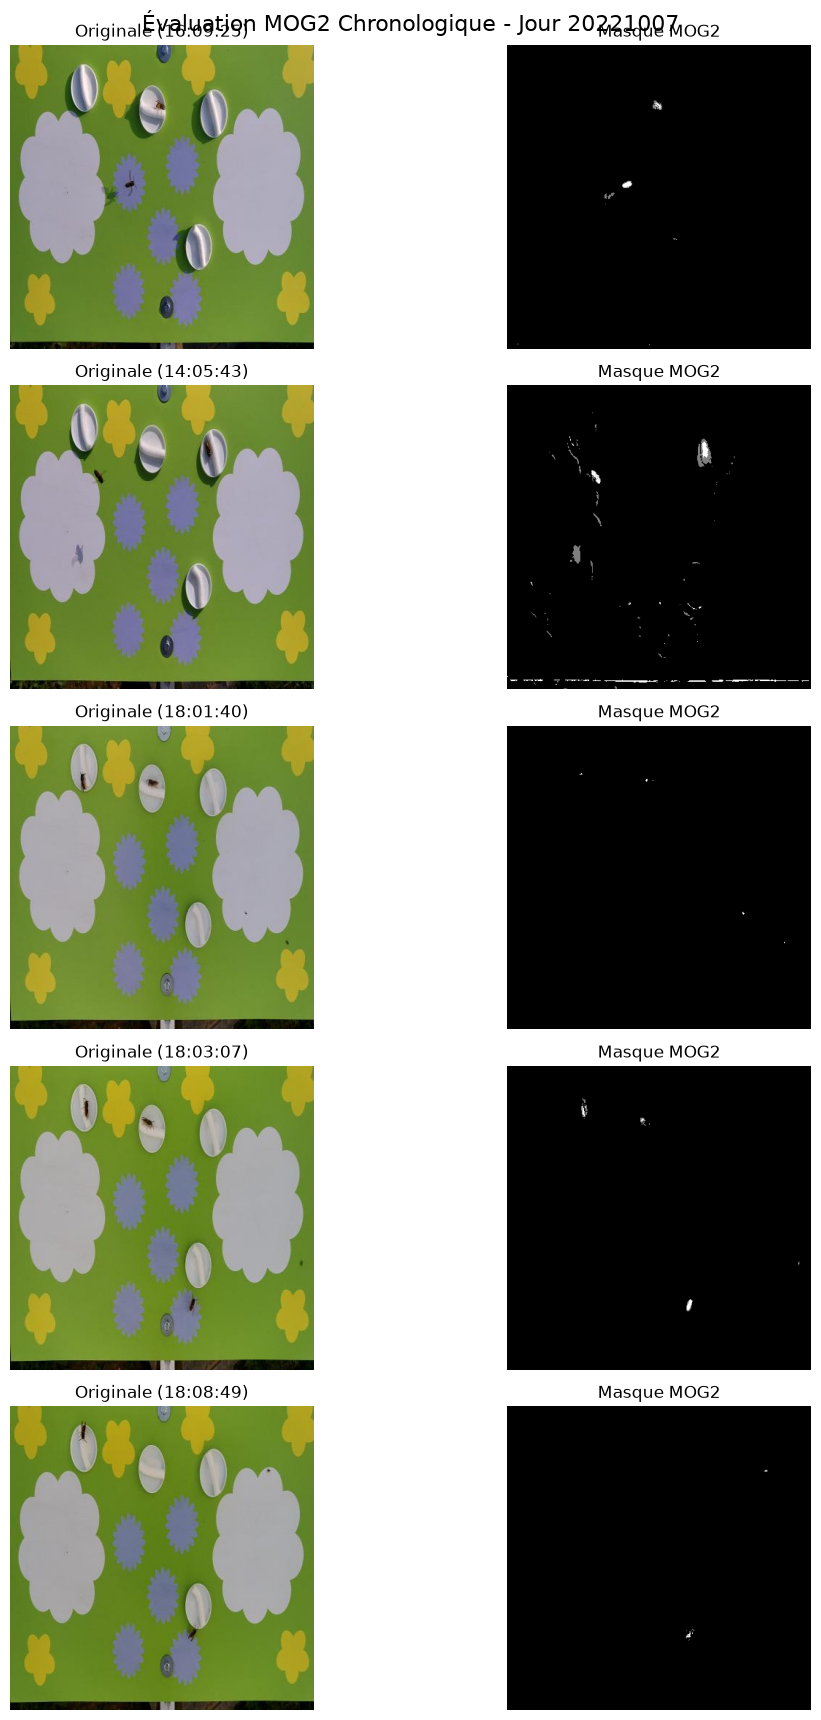


TRAITEMENT DE LA JOURNÉE : 20221012


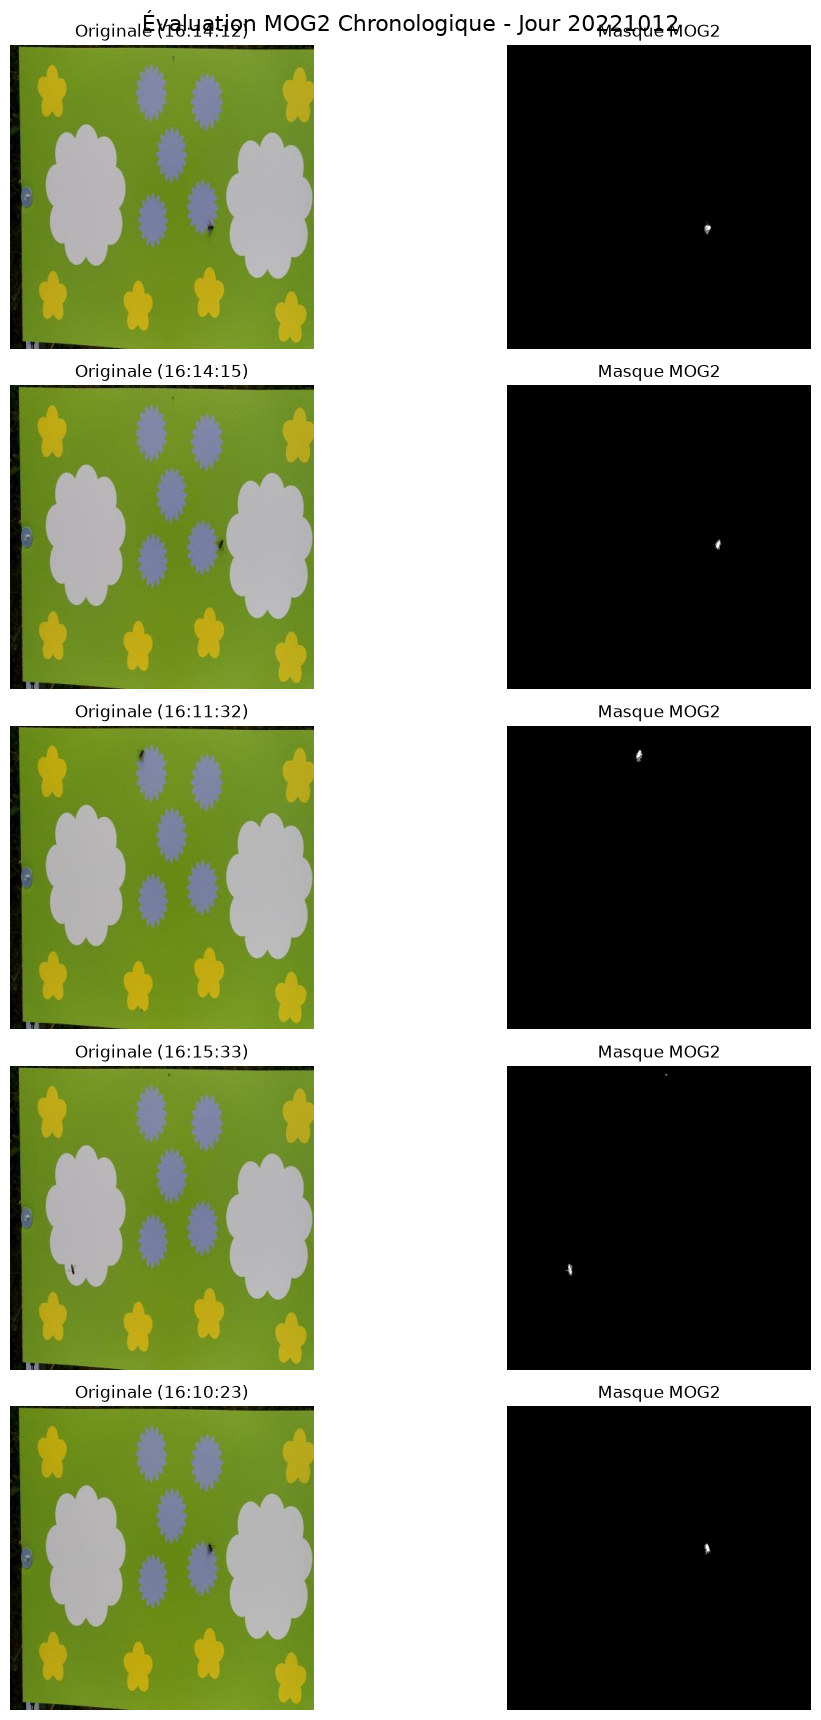


TRAITEMENT DE LA JOURNÉE : 20221017


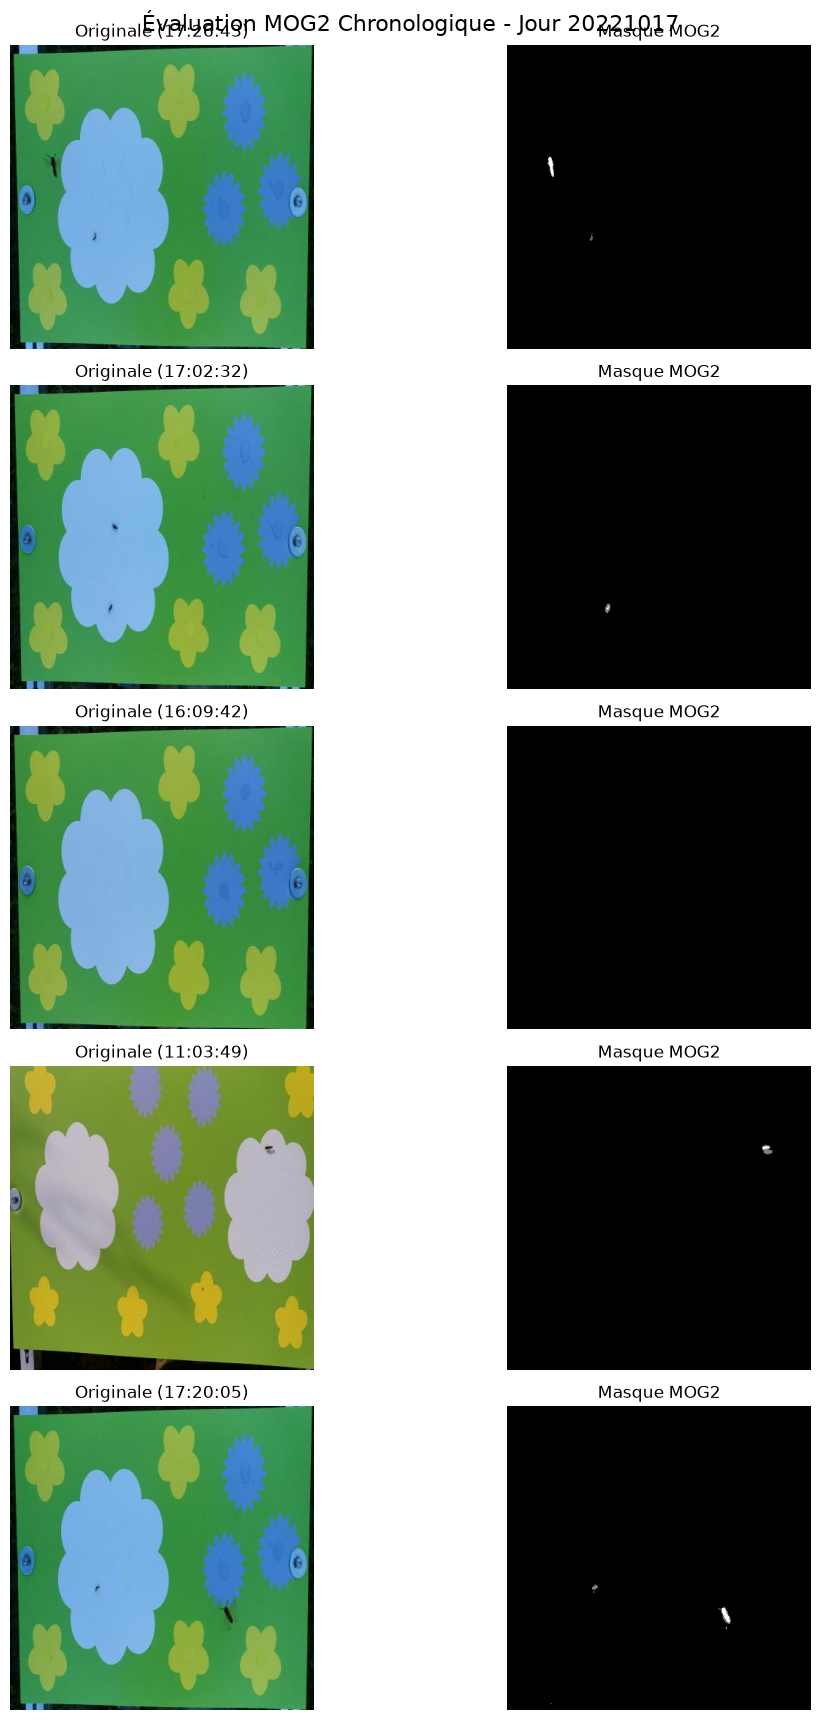

In [47]:
# On garde 8 images par jour
n_samples = 5 

for jour in jours_ajustement:
    print(f"\n{'='*40}")
    print(f"TRAITEMENT DE LA JOURNÉE : {jour}")
    print(f"{'='*40}")
    
    # Extraction des masques avec tes paramètres optimisés
    resultats_mog2 = apply_mog2_chronological_tuned(
        df_ajustement, 
        jour, 
        history=15, 
        var_threshold=100, 
        learning_rate=0.05
    )
    
    # Sélection aléatoire de 8 images
    echantillon = random.sample(resultats_mog2, min(n_samples, len(resultats_mog2)))
    
    # Affichage en grille : 8 lignes, 2 colonnes (Originale vs Masque)
    fig, axes = plt.subplots(len(echantillon), 2, figsize=(12, 3.5 * len(echantillon)))
    fig.suptitle(f"Évaluation MOG2 Chronologique - Jour {jour}", fontsize=16)
    
    for i, res in enumerate(echantillon):
        heure = res['image_name'][9:17].replace('-', ':')
        
        # 1. Originale
        axes[i, 0].imshow(cv2.cvtColor(res['original'], cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Originale ({heure})")
        axes[i, 0].axis('off')
        
        # 2. Masque Brut (qui est suffisamment net)
        axes[i, 1].imshow(res['mask_raw'], cmap='gray')
        axes[i, 1].set_title("Masque MOG2")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

### Comptage / clustering sur les masques de chaque image

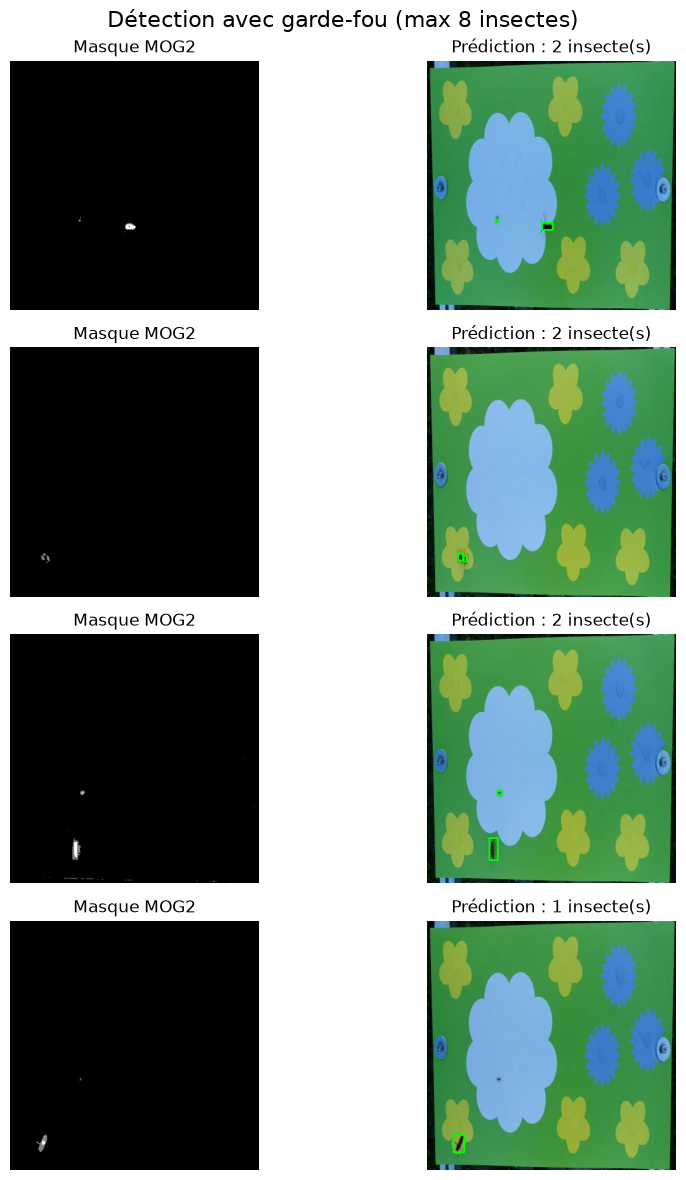

In [45]:
def count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8):
    """
    Extrait le nombre d'insectes. Si le nombre dépasse max_detections, 
    renvoie une erreur et annule les détections.
    """
    _, binary = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    valid_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area <= area <= max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            valid_boxes.append((x, y, w, h))
            
    nb_pred = len(valid_boxes)
    is_error = False
    
    # Le garde-fou : on considère l'image comme illisible/aberrante
    if nb_pred > max_detections:
        is_error = True
        nb_pred = 0
        valid_boxes = [] # On efface les boîtes aberrantes
        
    return nb_pred, valid_boxes, is_error

# --- Visualisation sur 4 images aléatoires ---
echantillon_4 = random.sample(resultats_mog2, min(4, len(resultats_mog2)))

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle("Détection avec garde-fou (max 8 insectes)", fontsize=16)

for i, res in enumerate(echantillon_4):
    mask = res['mask_raw']
    img_visu = res['original'].copy()
    
    nb_pred, boxes, is_error = count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8)
    
    for (x, y, w, h) in boxes:
        cv2.rectangle(img_visu, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
    axes[i, 0].imshow(mask, cmap='gray')
    axes[i, 0].set_title("Masque MOG2")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cv2.cvtColor(img_visu, cv2.COLOR_BGR2RGB))
    # Affichage spécifique si l'image est en erreur
    titre = "ERREUR (>8 détections)" if is_error else f"Prédiction : {nb_pred} insecte(s)"
    couleur_titre = 'red' if is_error else 'black'
    axes[i, 1].set_title(titre, color=couleur_titre)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

### Optimisation des paramètres (GridSearch) sur le jeu d'ajustement. 
### Objectif : atteindre le plus faible écart pour chaque jour entre nombre réel et nombre prédit d'insecte

In [49]:
import numpy as np
import pandas as pd
import itertools

def evaluate_mog2_params(df_day: pd.DataFrame, var_thresh: float, lr: float):
    df_day = df_day.sort_values("image_name")
    backSub = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=var_thresh, detectShadows=True)
    
    erreurs_absolues = []
    rejets = 0
    
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: 
            continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask_raw = backSub.apply(img_blur, learningRate=lr)
        
        nb_pred, _, is_error = count_insects_from_mask(mask_raw, min_area=5, max_area=700, max_detections=8)
        
        # Gestion du garde-fou
        if is_error:
            rejets += 1
            continue # On ne calcule pas la MAE sur une image considérée comme crashée
            
        nb_vrai = row['insect_count']
        erreurs_absolues.append(abs(nb_pred - nb_vrai))
        
    # S'il n'y a eu que des rejets, on renvoie une MAE infinie
    mae = np.mean(erreurs_absolues) if erreurs_absolues else float('inf')
    return mae, rejets

# --- Configuration de la GridSearch ---
learning_rates = [0.01, 0.05, 0.1, 0.2]
var_thresholds = [16, 30, 50, 100]
combinaisons = list(itertools.product(var_thresholds, learning_rates))

# Mise à jour de l'en-tête pour inclure les stats réelles
print(f"{'Jour':<10} | {'Stats Réelles (Min/Max/Moy)':<28} | {'varThresh':<10} | {'LR':<6} | {'MAE':<6} | {'Rejets'}")
print("-" * 85)

resultats_globaux = []

for jour in jours_ajustement:
    df_jour = df_ajustement[df_ajustement['jour'] == jour]

    # Extraction des statistiques réelles du jour
    min_reel = df_jour['insect_count'].min()
    max_reel = df_jour['insect_count'].max()
    moy_reel = df_jour['insect_count'].mean()
    stats_str = f"{min_reel} / {max_reel} / {moy_reel:.2f}"

    meilleure_mae = float('inf')
    meilleurs_params = None
    rejets_associes = 0
    
    for var_thresh, lr in combinaisons:
        mae, rejets = evaluate_mog2_params(df_jour, var_thresh, lr)
        
        if mae < meilleure_mae:
            meilleure_mae = mae
            meilleurs_params = (var_thresh, lr)
            rejets_associes = rejets
            
    resultats_globaux.append({
        'jour': jour,
        'var_threshold': meilleurs_params[0],
        'learning_rate': meilleurs_params[1],
        'mae': meilleure_mae
    })
    
    # Affichage de la ligne avec le contexte réel
    print(f"{jour:<10} | {stats_str:<28} | {meilleurs_params[0]:<10} | {meilleurs_params[1]:<6} | {meilleure_mae:.3f} | {rejets_associes}/{len(df_jour)}")

df_resultats = pd.DataFrame(resultats_globaux)
print("\n=== Paramètres médians à retenir pour le jeu de Test ===")
print(f"varThreshold : {df_resultats['var_threshold'].median()}")
print(f"learningRate : {df_resultats['learning_rate'].median()}")

Jour       | Stats Réelles (Min/Max/Moy)  | varThresh  | LR     | MAE    | Rejets
-------------------------------------------------------------------------------------
20221006   | 0 / 5 / 1.62                 | 100        | 0.05   | 0.586 | 14/386
20221007   | 0 / 4 / 2.44                 | 100        | 0.2    | 0.785 | 7/114
20221012   | 0 / 2 / 1.00                 | 30         | 0.01   | 0.093 | 41/95
20221017   | 0 / 4 / 1.68                 | 100        | 0.05   | 0.469 | 11/107

=== Paramètres médians à retenir pour le jeu de Test ===
varThreshold : 100.0
learningRate : 0.05


### Résultats sur le jeu de test : performances de comptage de l'approche MOG2



📊 RÉSULTATS DU TEST : JOUR 20221018 (148 images)
Garde-Fou   : 142 images validées | 6 images rejetées (4.1%)
Accuracy    : 49.3 % d'images avec prédiction PARFAITE
MAE         : 0.58 erreur en moyenne (moyenne réelle: 1.98 insectes/image)
WAPE        : 29.2 % d'erreur par rapport au volume total d'insectes
Pire erreur : Différence de 3 insectes sur l'image 20221018_09-01-14-040594_raw_jpg.rf.5c7612122f765d5ac77071df0afa2272.jpg


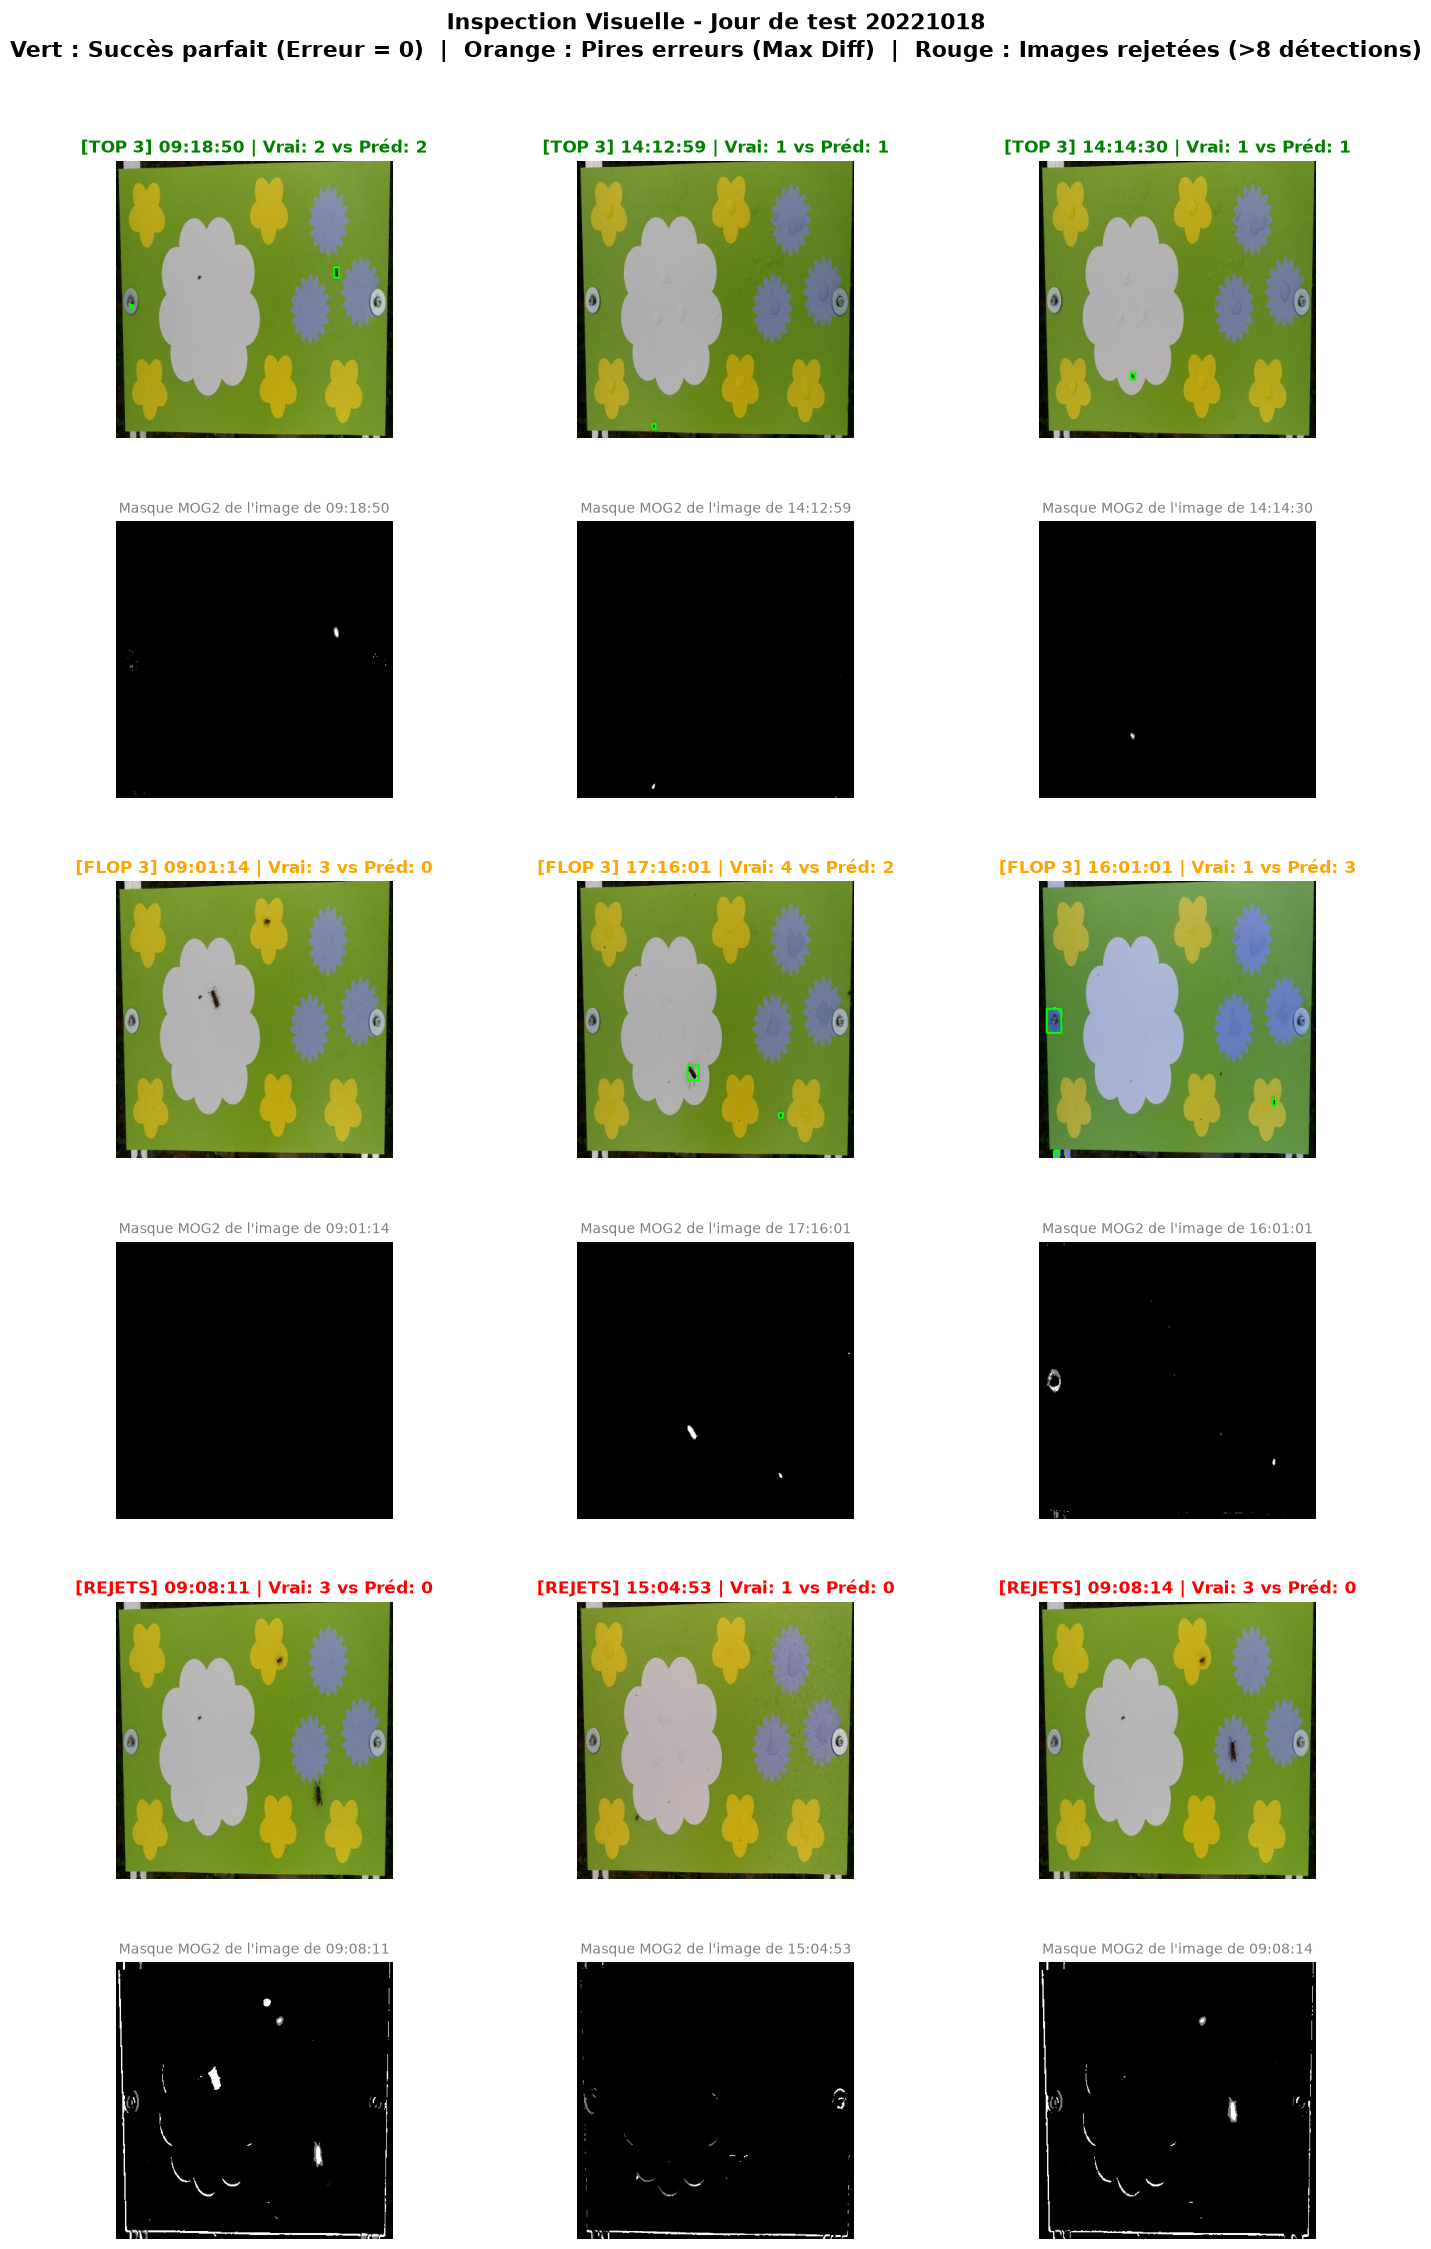



📊 RÉSULTATS DU TEST : JOUR 20221019 (185 images)
Garde-Fou   : 177 images validées | 8 images rejetées (4.3%)
Accuracy    : 46.9 % d'images avec prédiction PARFAITE
MAE         : 0.80 erreur en moyenne (moyenne réelle: 2.12 insectes/image)
WAPE        : 37.6 % d'erreur par rapport au volume total d'insectes
Pire erreur : Différence de 7 insectes sur l'image 20221019_16-12-36-177406_raw_jpg.rf.6d83bf617f8f87a8b70ba4edbb36ca62.jpg


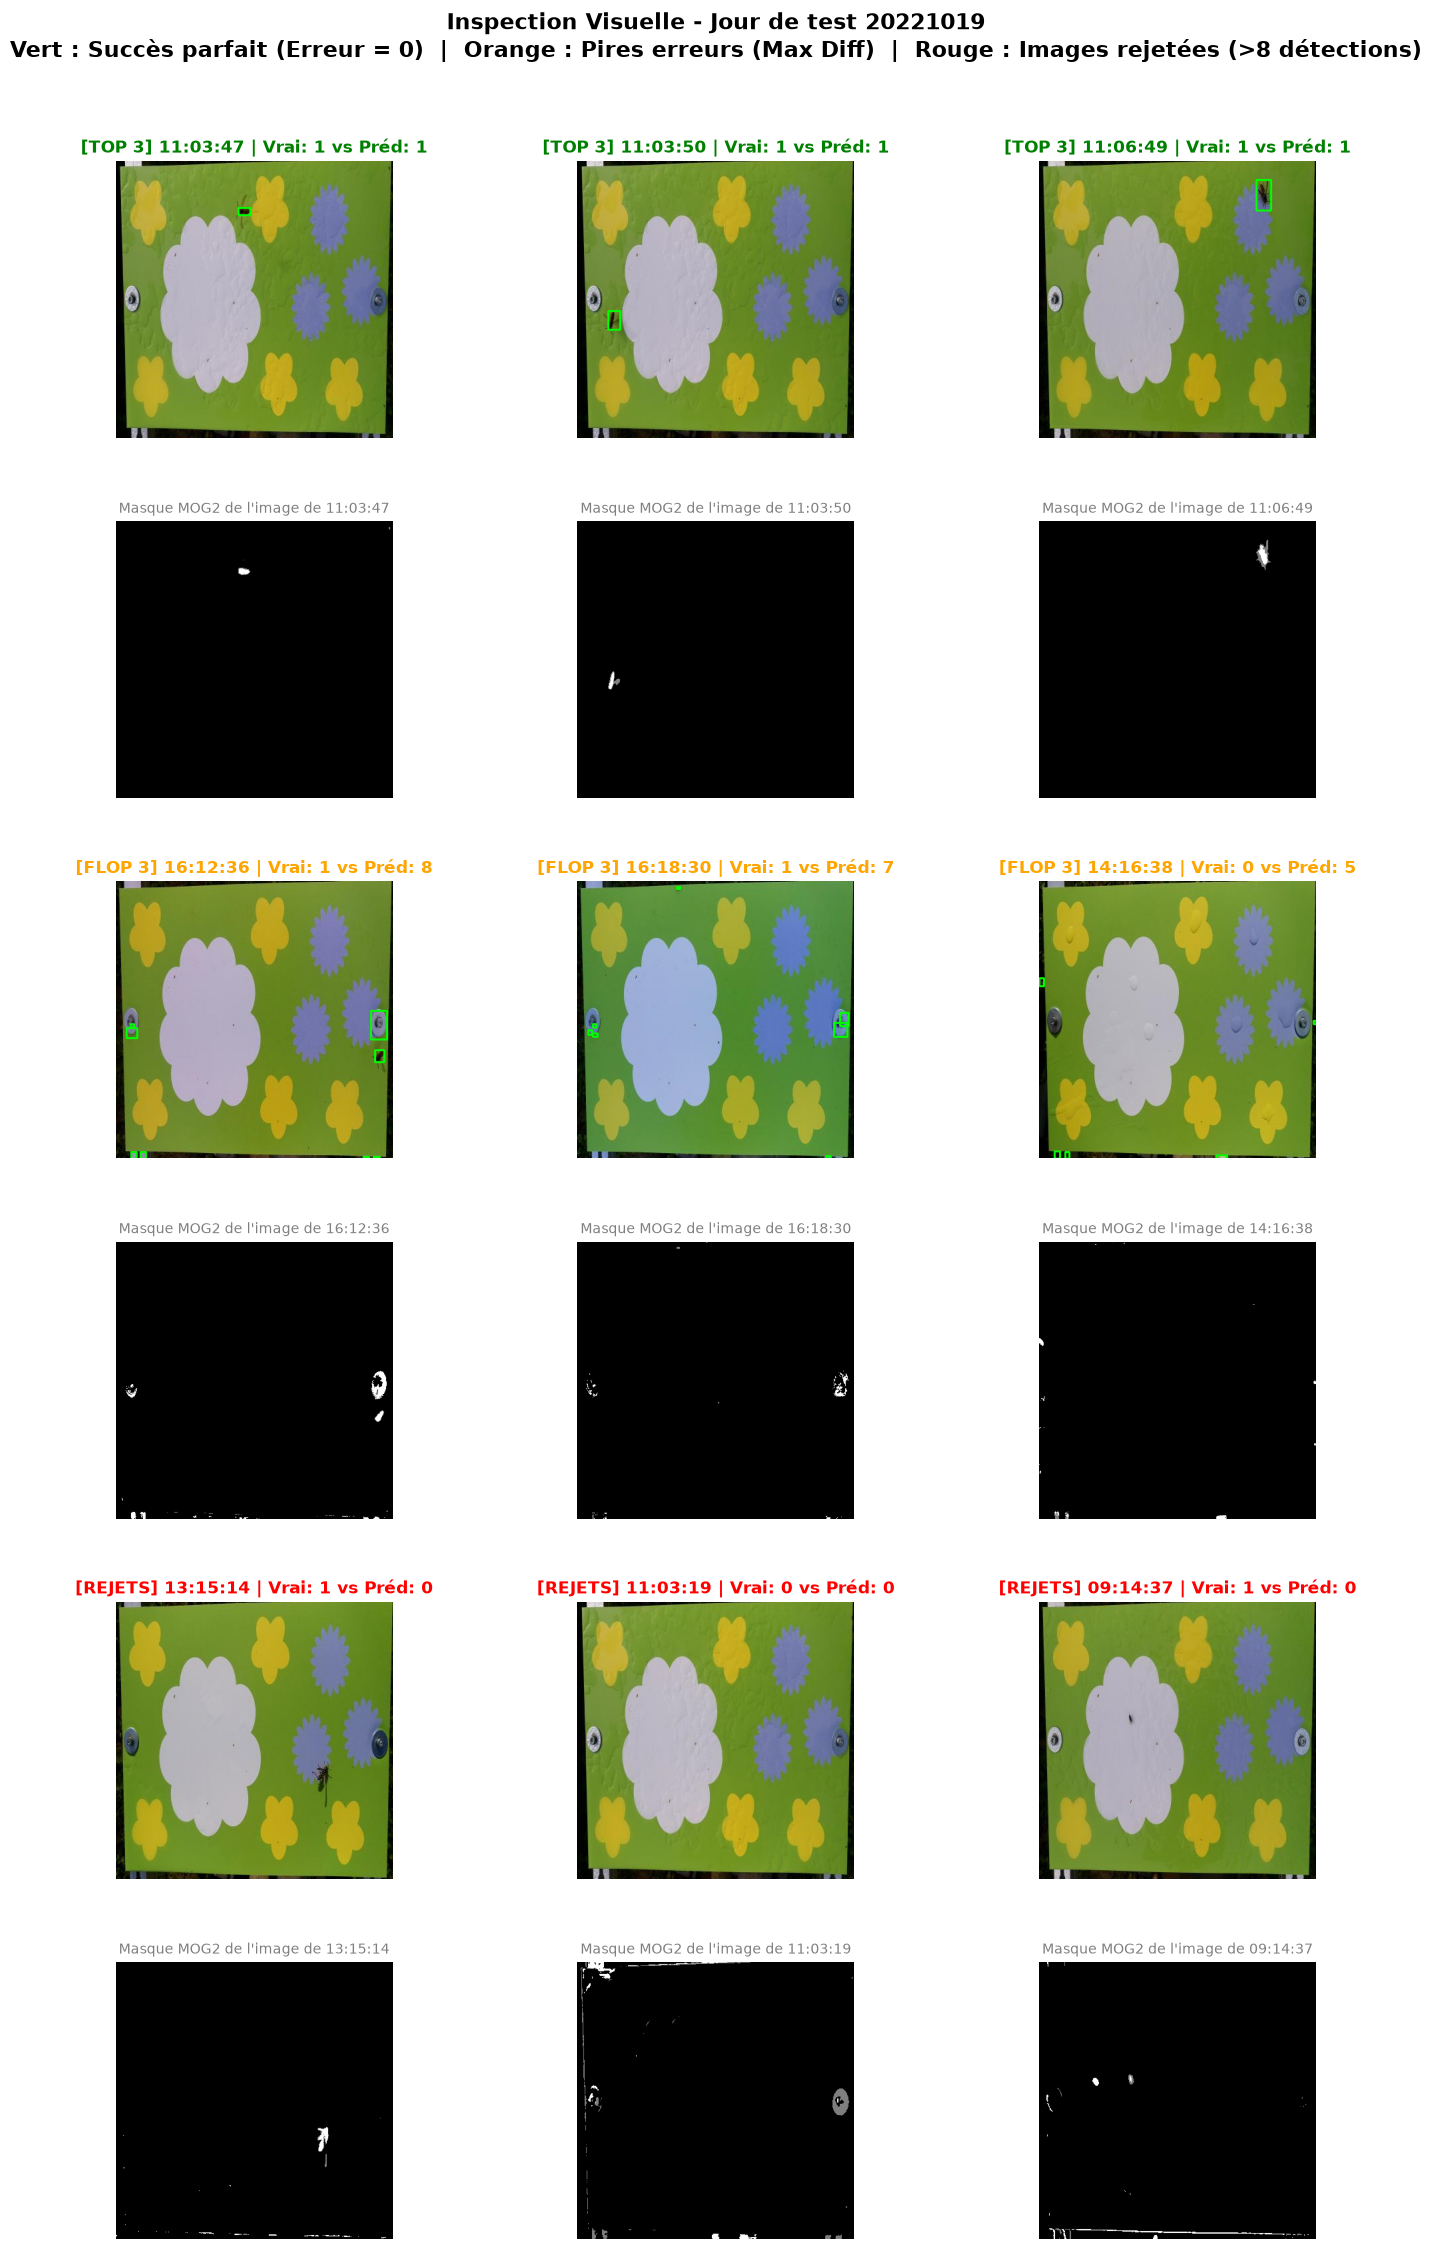



📊 RÉSULTATS DU TEST : JOUR 20221020 (66 images)
Garde-Fou   : 60 images validées | 6 images rejetées (9.1%)
Accuracy    : 73.3 % d'images avec prédiction PARFAITE
MAE         : 0.47 erreur en moyenne (moyenne réelle: 1.17 insectes/image)
WAPE        : 40.0 % d'erreur par rapport au volume total d'insectes
Pire erreur : Différence de 4 insectes sur l'image 20221020_11-26-30-828257_raw_jpg.rf.3c9714afc7020c1a31ea70bd37f60198.jpg


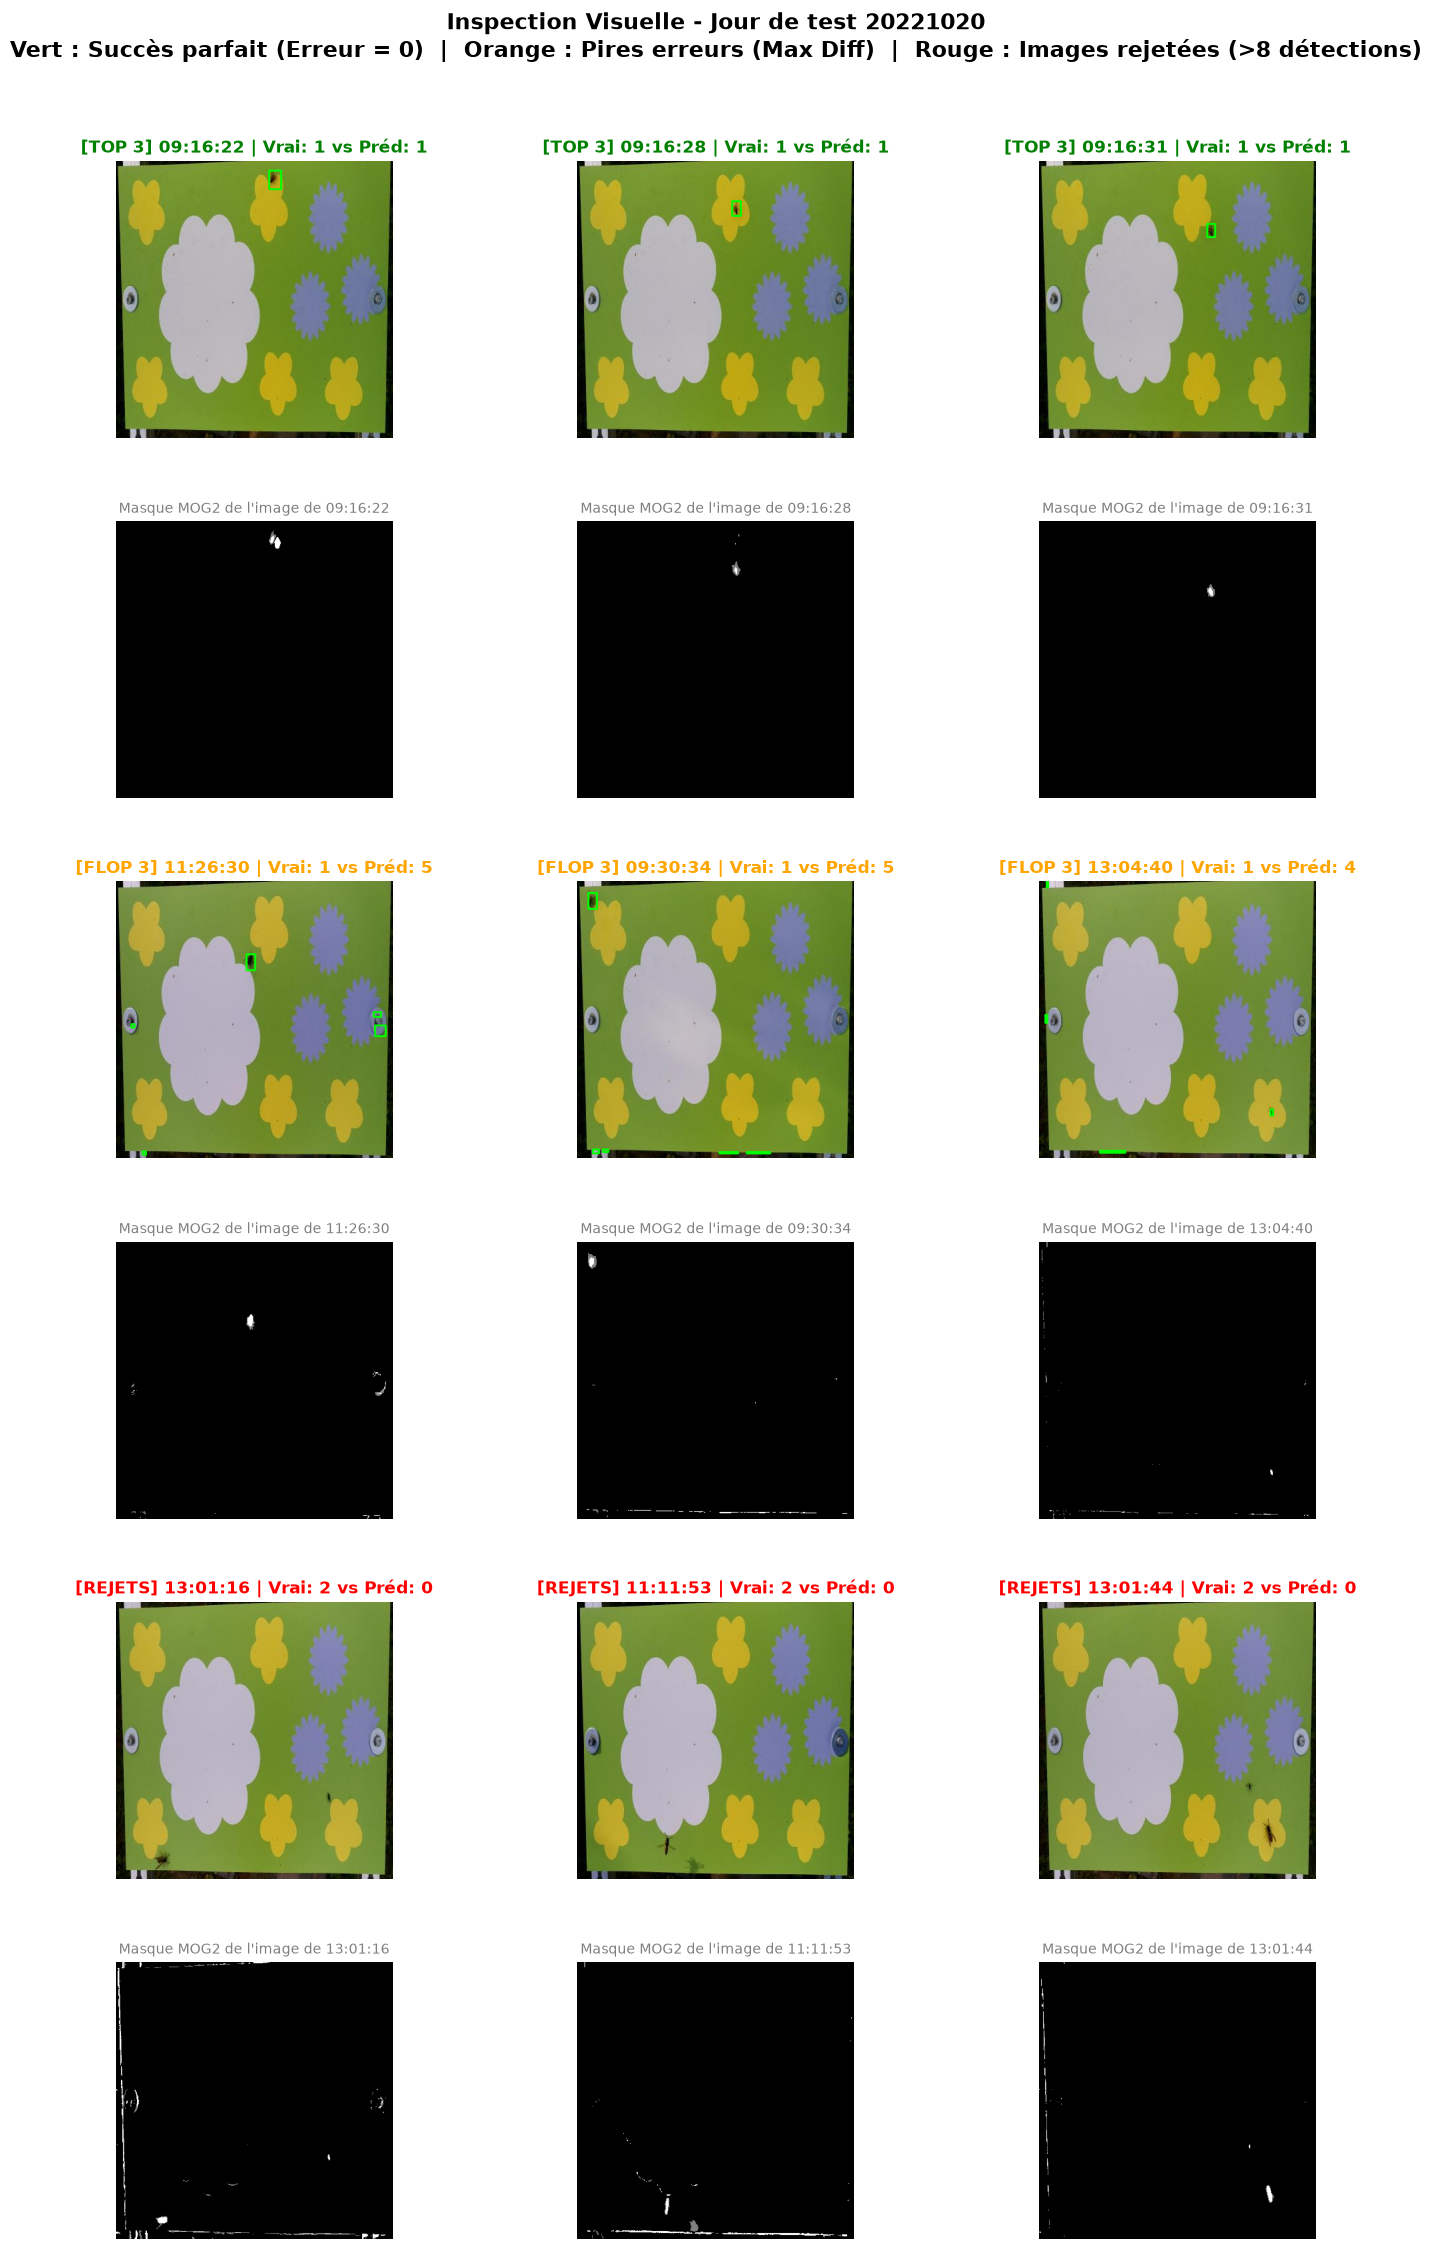



************************************************************
🌟 BILAN GLOBAL SUR LE JEU DE TEST (399 images au total)
************************************************************
Garde-Fou   : 379 validées | 20 rejetées (5.0%)
Accuracy    : 52.0 % d'images avec prédiction PARFAITE
MAE Globale : 0.66 erreur en moyenne (moyenne réelle globale: 1.92)
WAPE Global : 34.6 % d'erreur totale


In [57]:
# Paramètres figés issus de la GridSearch
VAR_THRESH_OPT = 100  # À remplacer par ta médiane
LR_OPT = 0.05        # À remplacer par ta médiane

def afficher_galerie_evaluation(top_3, flop_3, rejets_3, day):
    """Génère une grille 6x3 pour inspecter visuellement les prédictions et leurs masques."""
    # On agrandit la figure pour accommoder les 6 lignes
    fig, axes = plt.subplots(6, 3, figsize=(15, 22)) 
    
    titre_principal = (f"Inspection Visuelle - Jour de test {day}\n"
                       f"Vert : Succès parfait (Erreur = 0)  |  "
                       f"Orange : Pires erreurs (Max Diff)  |  "
                       f"Rouge : Images rejetées (>8 détections)")
    fig.suptitle(titre_principal, fontsize=16, y=1.02, fontweight='bold')
    
    # Structure : (Titre, données, couleur, index_de_la_ligne_image)
    categories = [
        ("TOP 3", top_3, 'green', 0),    # Les images à la ligne 0, les masques à la 1
        ("FLOP 3", flop_3, 'orange', 2), # Les images à la ligne 2, les masques à la 3
        ("REJETS", rejets_3, 'red', 4)   # Les images à la ligne 4, les masques à la 5
    ]
    
    for titre_cat, liste_images, couleur, row_img in categories:
        row_mask = row_img + 1 # Le masque est toujours sur la ligne juste en dessous
        
        for col_idx in range(3):
            ax_img = axes[row_img, col_idx]
            ax_mask = axes[row_mask, col_idx]
            
            if col_idx < len(liste_images):
                res = liste_images[col_idx]
                
                # --- Affichage de l'image ---
                img = cv2.imread(res['image_path'])
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                for (x, y, w, h) in res['boxes']:
                    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
                    
                ax_img.imshow(img_rgb)
                heure = res['image_name'][9:17].replace('-', ':')
                titre_image = f"[{titre_cat}] {heure} | Vrai: {res['nb_vrai']} vs Préd: {res['nb_pred']}"
                ax_img.set_title(titre_image, fontsize=12, color=couleur, fontweight='bold')
                
                # --- Affichage du masque ---
                ax_mask.imshow(res['mask'], cmap='gray')
                ax_mask.set_title(f"Masque MOG2 de l'image de {heure}", fontsize=10, color='gray')
                
            # Retirer les axes de toute façon (même pour les cases vides)
            ax_img.axis('off')
            ax_mask.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3) # Ajoute un peu d'espace vertical entre les rangées
    plt.show()

# --- Initialisation des compteurs globaux pour le bilan ---
global_N_total = 0
global_N_valide = 0
global_N_rejets = 0
global_total_vrai = 0
global_total_error = 0
global_images_parfaites = 0

# --- Exécution sur les jours de Test ---
jours_test = ['20221018', '20221019', '20221020']

for day in jours_test:
    df_day = df_test[df_test['jour'] == day].sort_values("image_name")
    backSub = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=VAR_THRESH_OPT, detectShadows=True)
    
    resultats_valides = []
    rejets = []
    
    # 1. Phase de Prédiction
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask_raw = backSub.apply(img_blur, learningRate=LR_OPT)
        
        nb_pred, boxes, is_error = count_insects_from_mask(mask_raw, min_area=5, max_area=700, max_detections=8)
        nb_vrai = row['insect_count']
        
        dictionnaire_resultat = {
            'image_name': row['image_name'],
            'image_path': row['image_path'],
            'nb_vrai': nb_vrai,
            'nb_pred': nb_pred,
            'error': abs(nb_pred - nb_vrai),
            'boxes': boxes,
            'mask': mask_raw
        }
        
        if is_error:
            rejets.append(dictionnaire_resultat)
        else:
            resultats_valides.append(dictionnaire_resultat)
            
    # 2. Calcul des Métriques Journalières
    N_total = len(df_day)
    N_valide = len(resultats_valides)
    N_rejets = len(rejets)
    
    # Mise à jour des compteurs globaux
    global_N_total += N_total
    global_N_valide += N_valide
    global_N_rejets += N_rejets
    
    print(f"\n\n{'='*60}")
    print(f"📊 RÉSULTATS DU TEST : JOUR {day} ({N_total} images)")
    print(f"{'='*60}")
    
    if N_valide > 0:
        resultats_valides.sort(key=lambda x: x['error'])
        
        total_vrai = sum(r['nb_vrai'] for r in resultats_valides)
        total_error = sum(r['error'] for r in resultats_valides)
        images_parfaites = sum(1 for r in resultats_valides if r['error'] == 0)
        
        # Mise à jour des compteurs globaux (suite)
        global_total_vrai += total_vrai
        global_total_error += total_error
        global_images_parfaites += images_parfaites
        
        moyenne_vrai = total_vrai / N_valide
        mae = total_error / N_valide
        wape = (total_error / total_vrai * 100) if total_vrai > 0 else 0
        accuracy = (images_parfaites / N_valide) * 100
        pire_cas = resultats_valides[-1] 
        
        print(f"Garde-Fou   : {N_valide} images validées | {N_rejets} images rejetées ({(N_rejets/N_total)*100:.1f}%)")
        print(f"Accuracy    : {accuracy:.1f} % d'images avec prédiction PARFAITE")
        print(f"MAE         : {mae:.2f} erreur en moyenne (moyenne réelle: {moyenne_vrai:.2f} insectes/image)")
        print(f"WAPE        : {wape:.1f} % d'erreur par rapport au volume total d'insectes")
        print(f"Pire erreur : Différence de {pire_cas['error']} insectes sur l'image {pire_cas['image_name']}")
        
        # 3. Extraction visuelle
        top_3 = [r for r in resultats_valides if r['error'] == 0][:3]
        flop_3 = resultats_valides[-3:][::-1]
        rejets_3 = random.sample(rejets, min(3, N_rejets)) if N_rejets > 0 else []
        
        afficher_galerie_evaluation(top_3, flop_3, rejets_3, day)
    else:
        print("Toutes les images de cette journée ont été rejetées par le plafond (>8 détections).")

# --- 4. Bilan Global sur les 3 jours ---
print(f"\n\n{'*'*60}")
print(f"🌟 BILAN GLOBAL SUR LE JEU DE TEST ({global_N_total} images au total)")
print(f"{'*'*60}")

if global_N_valide > 0:
    global_moyenne_vrai = global_total_vrai / global_N_valide
    global_mae = global_total_error / global_N_valide
    global_wape = (global_total_error / global_total_vrai * 100) if global_total_vrai > 0 else 0
    global_accuracy = (global_images_parfaites / global_N_valide) * 100
    
    print(f"Garde-Fou   : {global_N_valide} validées | {global_N_rejets} rejetées ({(global_N_rejets/global_N_total)*100:.1f}%)")
    print(f"Accuracy    : {global_accuracy:.1f} % d'images avec prédiction PARFAITE")
    print(f"MAE Globale : {global_mae:.2f} erreur en moyenne (moyenne réelle globale: {global_moyenne_vrai:.2f})")
    print(f"WAPE Global : {global_wape:.1f} % d'erreur totale")
else:
    print("Aucune donnée valide pour générer des statistiques globales.")

### Resultats sur le jeu de test : étude des Bounding Boxes prédites / réelles

In [67]:
def parse_yolo_labels(label_path, img_width, img_height):
    """Convertit les coordonnées YOLO normalisées en Bounding Boxes absolues (x, y, w, h)."""
    true_boxes = []
    if Path(label_path).exists():
        with open(label_path, 'r') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
            for line in lines:
                parts = line.split()
                if len(parts) >= 5:
                    # YOLO format : class_id x_center y_center width height (normalisés 0-1)
                    x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                    
                    w = int(w_norm * img_width)
                    h = int(h_norm * img_height)
                    x = int((x_c * img_width) - (w / 2))
                    y = int((y_c * img_height) - (h / 2))
                    true_boxes.append((x, y, w, h))
    return true_boxes

def compute_io_min(box1, box2):
    """Calcule l'Intersection sur Minimum (IoM) entre deux Bounding Boxes."""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # Coordonnées de l'intersection
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    if inter_area == 0:
        return 0.0
        
    # Aires respectives
    box1_area = w1 * h1
    box2_area = w2 * h2
    
    # Au lieu de l'Union, on prend l'aire minimale
    min_area = min(box1_area, box2_area)
    
    return inter_area / min_area

def evaluate_detections_forgiving(pred_boxes, true_boxes, overlap_threshold=0.5):
    """
    Associe les prédictions aux vrais insectes en utilisant l'IoM.
    Un seuil de 0.5 exige que la moitié de la plus petite boîte soit recouverte.
    """
    matched_true = set()
    true_positives = 0
    
    for p_box in pred_boxes:
        best_iom = 0
        best_t_idx = -1
        
        for t_idx, t_box in enumerate(true_boxes):
            if t_idx in matched_true:
                continue
                
            iom = compute_io_min(p_box, t_box)
            if iom > best_iom:
                best_iom = iom
                best_t_idx = t_idx
                
        if best_iom >= overlap_threshold:
            true_positives += 1
            matched_true.add(best_t_idx)
            
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(true_boxes) - true_positives
    
    return true_positives, false_positives, false_negatives

# --- Exécution de l'évaluation spatiale ---
# Ajuste le chemin vers ton dossier de labels si nécessaire
LABELS_DIR = Path("../data/merged_filtered_dataset/labels") 

jours_test = ['20221018', '20221019', '20221020']

global_tp, global_fp, global_fn = 0, 0, 0

for day in jours_test:
    df_day = df_test[df_test['jour'] == day].sort_values("image_name")
    backSub = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=VAR_THRESH_OPT, detectShadows=True)
    
    day_tp, day_fp, day_fn = 0, 0, 0
    
    for _, row in df_day.iterrows():
        img_path = Path(row['image_path'])
        img = cv2.imread(str(img_path))
        if img is None: continue
        
        h_img, w_img = img.shape[:2]
        
        # 1. Parsing YOLO
        label_name = img_path.with_suffix(".txt").name
        label_file = LABELS_DIR / label_name
        true_boxes = parse_yolo_labels(label_file, w_img, h_img)
        
        # 2. Prédiction OpenCV
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask_raw = backSub.apply(img_blur, learningRate=LR_OPT)
        _, pred_boxes, is_error = count_insects_from_mask(mask_raw, min_area=5, max_area=700, max_detections=8)
        
        # Si le garde-fou a rejeté l'image, on compte 0 prédiction (tout est faux négatif)
        if is_error:
            pred_boxes = []
            
        # 3. Association et Métriques
        tp, fp, fn = evaluate_detections_forgiving(pred_boxes, true_boxes, overlap_threshold=0.5)
        day_tp += tp
        day_fp += fp
        day_fn += fn
        
    global_tp += day_tp
    global_fp += day_fp
    global_fn += day_fn
    
    precision = (day_tp / (day_tp + day_fp)) * 100 if (day_tp + day_fp) > 0 else 0
    recall = (day_tp / (day_tp + day_fn)) * 100 if (day_tp + day_fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{'='*55}")
    print(f"🎯 ÉVALUATION SPATIALE : JOUR {day}")
    print(f"{'='*55}")
    print(f"Vrais Positifs (Insectes bien localisés) : {day_tp}")
    print(f"Faux Positifs (Bruit/Ombres détectés)    : {day_fp}")
    print(f"Faux Négatifs (Insectes ratés)           : {day_fn}")
    print(f"-"*55)
    print(f"Précision (Qualité des boîtes tracées)   : {precision:.1f} %")
    print(f"Rappel    (Exhaustivité de détection)    : {recall:.1f} %")
    print(f"F1-Score  (Équilibre global)             : {f1_score:.1f} %")

# --- Bilan Spatial Global ---
g_precision = (global_tp / (global_tp + global_fp)) * 100 if (global_tp + global_fp) > 0 else 0
g_recall = (global_tp / (global_tp + global_fn)) * 100 if (global_tp + global_fn) > 0 else 0
g_f1_score = (2 * g_precision * g_recall) / (g_precision + g_recall) if (g_precision + g_recall) > 0 else 0

print(f"\n\n{'*'*55}")
print(f"🌟 BILAN SPATIAL GLOBAL SUR LE JEU DE TEST")
print(f"{'*'*55}")
print(f"Précision Globale : {g_precision:.1f} %")
print(f"Rappel Global     : {g_recall:.1f} %")
print(f"F1-Score Global   : {g_f1_score:.1f} %")


🎯 ÉVALUATION SPATIALE : JOUR 20221018
Vrais Positifs (Insectes bien localisés) : 199
Faux Positifs (Bruit/Ombres détectés)    : 10
Faux Négatifs (Insectes ratés)           : 93
-------------------------------------------------------
Précision (Qualité des boîtes tracées)   : 95.2 %
Rappel    (Exhaustivité de détection)    : 68.2 %
F1-Score  (Équilibre global)             : 79.4 %

🎯 ÉVALUATION SPATIALE : JOUR 20221019
Vrais Positifs (Insectes bien localisés) : 292
Faux Positifs (Bruit/Ombres détectés)    : 88
Faux Négatifs (Insectes ratés)           : 91
-------------------------------------------------------
Précision (Qualité des boîtes tracées)   : 76.8 %
Rappel    (Exhaustivité de détection)    : 76.2 %
F1-Score  (Équilibre global)             : 76.5 %

🎯 ÉVALUATION SPATIALE : JOUR 20221020
Vrais Positifs (Insectes bien localisés) : 68
Faux Positifs (Bruit/Ombres détectés)    : 28
Faux Négatifs (Insectes ratés)           : 11
-------------------------------------------------------

### Etude de l'IoU

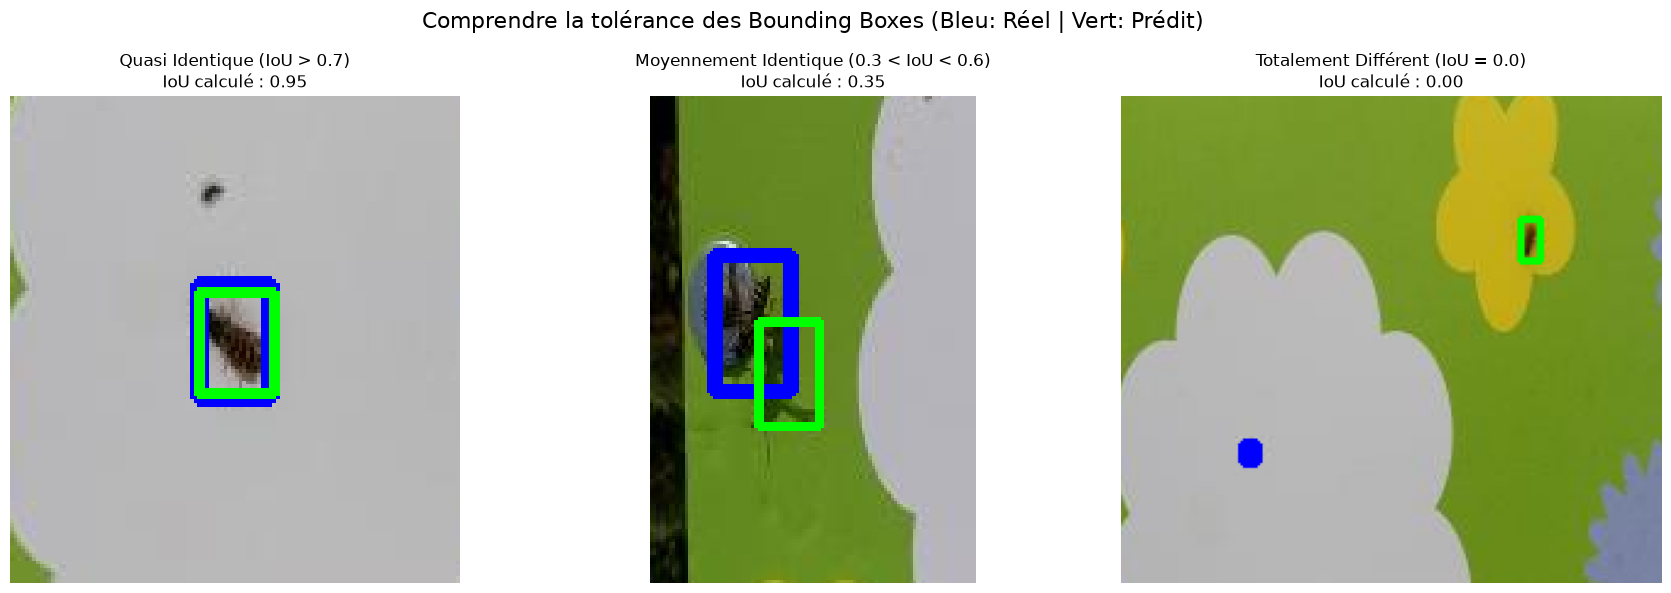

In [68]:
def trouver_exemples_iom(df, labels_dir, backSub, lr_opt):
    """Parcourt le jeu de test pour dénicher des cas spécifiques d'IoU."""
    exemples = {'parfait': None, 'moyen': None, 'echec': None}
    
    for _, row in df.iterrows():
        # Si on a trouvé nos 3 exemples, on arrête la recherche
        if all(exemples.values()):
            break
            
        img_path = Path(row['image_path'])
        img = cv2.imread(str(img_path))
        if img is None: continue
        
        # Vraies boîtes
        label_file = labels_dir / img_path.with_suffix(".txt").name
        true_boxes = parse_yolo_labels(label_file, img.shape[1], img.shape[0])
        if not true_boxes: continue
            
        # Boîtes prédites
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask = backSub.apply(img_blur, learningRate=lr_opt)
        _, pred_boxes, _ = count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8)
        
        if not pred_boxes: continue

        # On teste l'IoU de la première prédiction avec la première vraie boîte
        iou = compute_io_min(pred_boxes[0], true_boxes[0])
        
        res_dict = {'img': img.copy(), 't_box': true_boxes[0], 'p_box': pred_boxes[0], 'iou': iou}
        
        if iou > 0.7 and exemples['parfait'] is None:
            exemples['parfait'] = res_dict
        elif 0.3 <= iou <= 0.6 and exemples['moyen'] is None:
            exemples['moyen'] = res_dict
        elif iou == 0.0 and exemples['echec'] is None:
            # S'assurer qu'il y a bien une vraie boîte et une prédiction, mais qui ne se touchent pas du tout
            exemples['echec'] = res_dict
            
    return exemples

# --- Exécution et Affichage ---
# On réinitialise l'algo pour une recherche neutre
backSub_visu = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=VAR_THRESH_OPT, detectShadows=True)
exemples_trouves = trouver_exemples_iom(df_test, LABELS_DIR, backSub_visu, LR_OPT)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comprendre la tolérance des Bounding Boxes (Bleu: Réel | Vert: Prédit)", fontsize=16)

titres = [
    ("Quasi Identique (IoU > 0.7)", 'parfait'),
    ("Moyennement Identique (0.3 < IoU < 0.6)", 'moyen'),
    ("Totalement Différent (IoU = 0.0)", 'echec')
]

for idx, (titre, cle) in enumerate(titres):
    ax = axes[idx]
    data = exemples_trouves[cle]
    
    if data is not None:
        img_draw = cv2.cvtColor(data['img'], cv2.COLOR_BGR2RGB)
        
        # Vraie boîte en BLEU
        x, y, w, h = data['t_box']
        cv2.rectangle(img_draw, (x, y), (x+w, y+h), (0, 0, 255), 3) # OpenCV utilise RGB ici car on a converti
        
        # Boîte prédite en VERT
        xp, yp, wp, hp = data['p_box']
        cv2.rectangle(img_draw, (xp, yp), (xp+wp, yp+hp), (0, 255, 0), 2)
        
        # Zoomer sur la zone d'intérêt pour bien voir la différence
        marge = 50
        x_min = max(0, min(x, xp) - marge)
        y_min = max(0, min(y, yp) - marge)
        x_max = min(img_draw.shape[1], max(x+w, xp+wp) + marge)
        y_max = min(img_draw.shape[0], max(y+h, yp+hp) + marge)
        
        ax.imshow(img_draw[y_min:y_max, x_min:x_max])
        ax.set_title(f"{titre}\nIoU calculé : {data['iou']:.2f}")
    else:
        ax.set_title(f"{titre}\n(Aucun exemple trouvé dans ce run)")
        
    ax.axis('off')

plt.tight_layout()
plt.show()